1. CZ → CX using H:



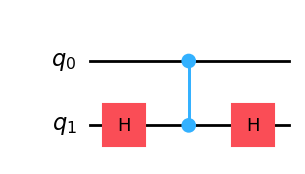

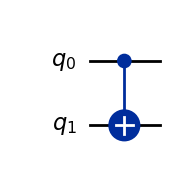

Matrix check:


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>


2. Control/Target Swap using H:



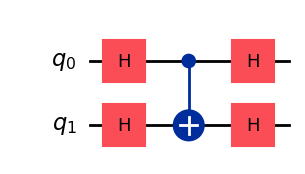

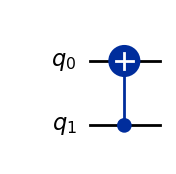

Matrix check:


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>


3. SWAP from 3 CX:



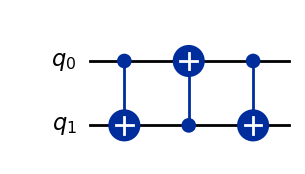

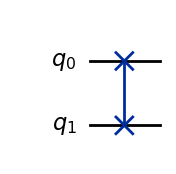

Matrix check:


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [1]:
# ============================================================
# IMPORTANT CIRCUIT IDENTITIES (CZ ↔ CX, Hadamard swap, SWAP)
# ============================================================

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector, Operator
from IPython.display import display

# ============================================================
# 1. CZ ↔ CX using Hadamard
# ============================================================
# Identity:
# (I ⊗ H) CZ (I ⊗ H) = CX
#
# Meaning:
# - Apply H before and after target → Z becomes X
# - Converts CZ into CX

q = QuantumRegister(2, 'q')

# LHS: H - CZ - H (on target)
qc1_lhs = QuantumCircuit(q)
qc1_lhs.h(q[1])
qc1_lhs.cz(q[0], q[1])
qc1_lhs.h(q[1])

# RHS: CX
qc1_rhs = QuantumCircuit(q)
qc1_rhs.cx(q[0], q[1])

print("1. CZ → CX using H:\n")
display(qc1_lhs.draw(output='mpl'))
display(qc1_rhs.draw(output='mpl'))

print("Matrix check:")
display(Operator(qc1_lhs).draw("latex"))
display(Operator(qc1_rhs).draw("latex"))


# ============================================================
# 2. Hadamard transforms control/target
# ============================================================
# Identity:
# (H ⊗ H) CX (H ⊗ H) = CX (control ↔ target)
#
# Meaning:
# - H swaps X ↔ Z basis
# - effectively flips direction of control

# LHS
qc2_lhs = QuantumCircuit(q)
qc2_lhs.h(q[0])
qc2_lhs.h(q[1])
qc2_lhs.cx(q[0], q[1])
qc2_lhs.h(q[0])
qc2_lhs.h(q[1])

# RHS (reversed control)
qc2_rhs = QuantumCircuit(q)
qc2_rhs.cx(q[1], q[0])

print("\n2. Control/Target Swap using H:\n")
display(qc2_lhs.draw(output='mpl'))
display(qc2_rhs.draw(output='mpl'))

print("Matrix check:")
display(Operator(qc2_lhs).draw("latex"))
display(Operator(qc2_rhs).draw("latex"))


# ============================================================
# 3. SWAP Gate using 3 CX
# ============================================================
# Identity:
# SWAP = CX(0,1) → CX(1,0) → CX(0,1)
#
# Meaning:
# - Exchanges two qubits completely

# LHS: 3 CX gates
qc3_lhs = QuantumCircuit(q)
qc3_lhs.cx(q[0], q[1])
qc3_lhs.cx(q[1], q[0])
qc3_lhs.cx(q[0], q[1])

# RHS: built-in SWAP
qc3_rhs = QuantumCircuit(q)
qc3_rhs.swap(q[0], q[1])

print("\n3. SWAP from 3 CX:\n")
display(qc3_lhs.draw(output='mpl'))
display(qc3_rhs.draw(output='mpl'))

print("Matrix check:")
display(Operator(qc3_lhs).draw("latex"))
display(Operator(qc3_rhs).draw("latex"))